# Exploratory Data Analysis
Telco Customer Churn Dataset

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

In [2]:
from src.preprocessing import load_data

df = load_data('../dataset/Telco_customer_churn.xlsx')
print('Shape:', df.shape)
df.head()

Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [4]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2279.734304,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.794470,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,398.550000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1394.550000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3786.600000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


In [5]:
# check missing values
print(df.isnull().sum()[df.isnull().sum() > 0])

Churn Reason    5174
dtype: int64


## Churn Distribution

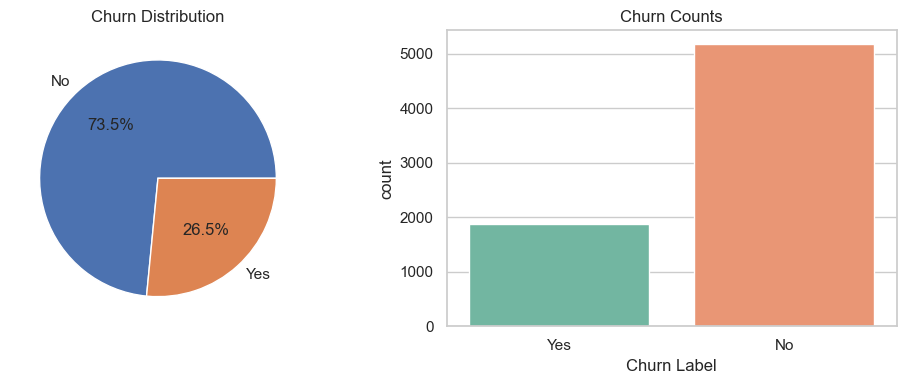

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['Churn Label'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'])
axes[0].set_title('Churn Distribution')

sns.countplot(x='Churn Label', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Churn Counts')

plt.tight_layout()
plt.savefig('../outputs/figures/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(counts)

## Numerical Features

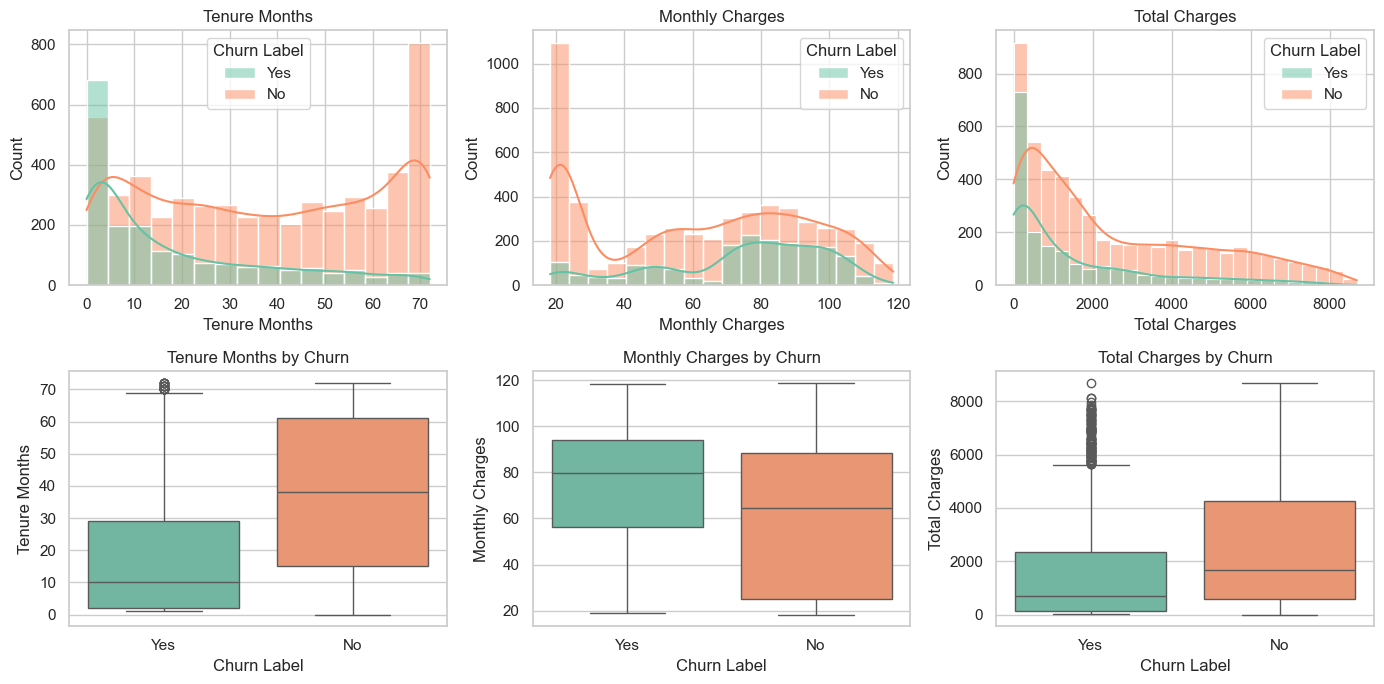

In [7]:
num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='Churn Label', kde=True, ax=axes[0, i], palette='Set2')
    axes[0, i].set_title(col)

    sns.boxplot(data=df, x='Churn Label', y=col, ax=axes[1, i], palette='Set2')
    axes[1, i].set_title(col + ' by Churn')

plt.tight_layout()
plt.savefig('../outputs/figures/02_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Categorical Features vs Churn

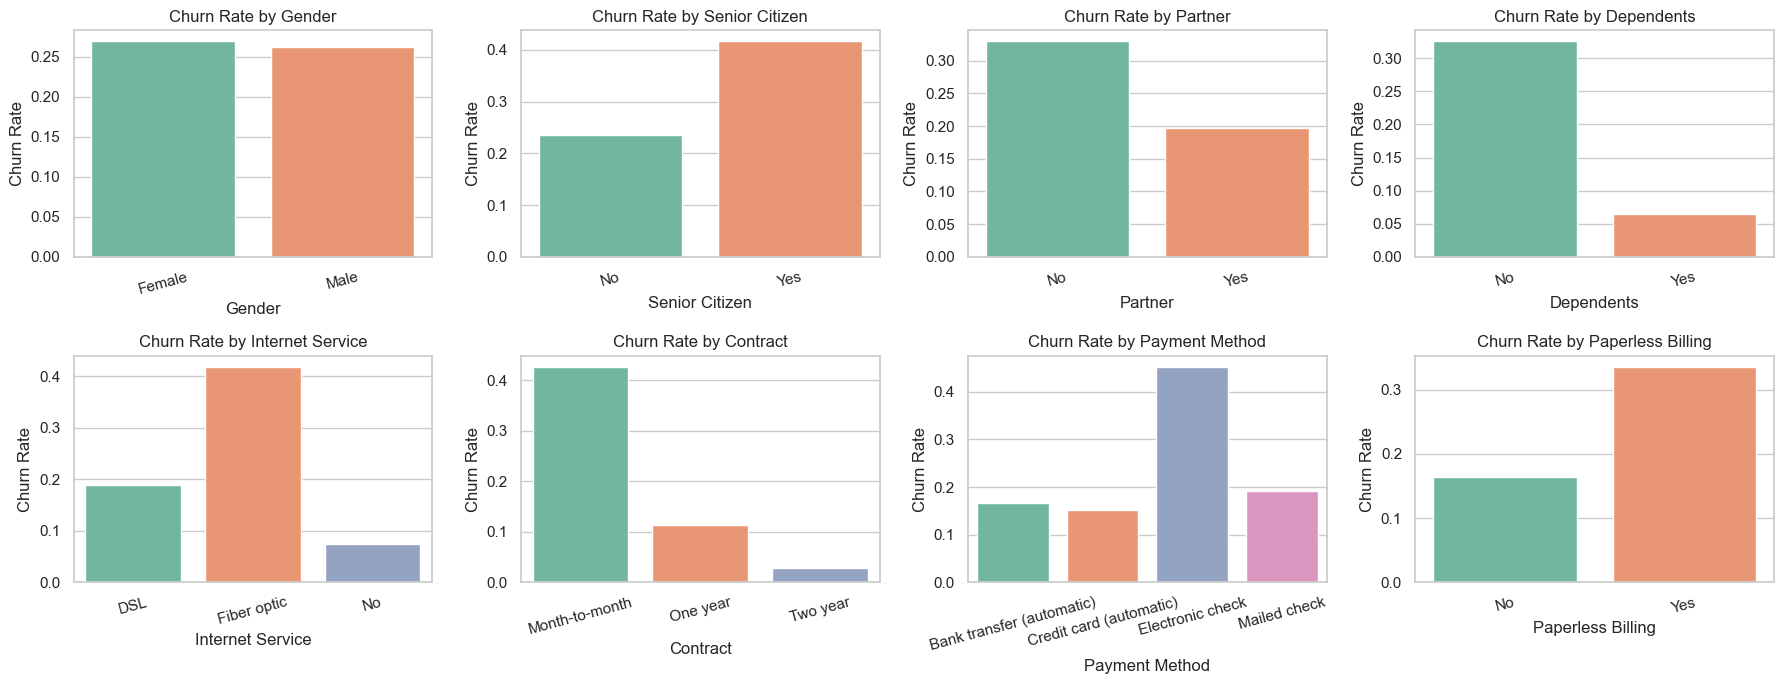

In [8]:
cat_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents',
            'Internet Service', 'Contract', 'Payment Method', 'Paperless Billing']

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn Value'].mean().reset_index()
    sns.barplot(data=churn_rate, x=col, y='Churn Value', ax=axes[i], palette='Set2')
    axes[i].set_title('Churn Rate by ' + col)
    axes[i].set_ylabel('Churn Rate')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../outputs/figures/03_categorical_churn_rates.png', dpi=150, bbox_inches='tight')
plt.show()

## Correlation Heatmap

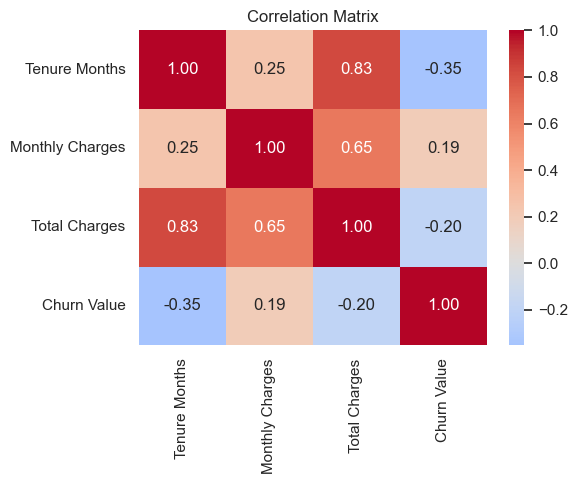

In [9]:
corr_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value']
corr = df[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('../outputs/figures/04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Service Subscriptions vs Churn

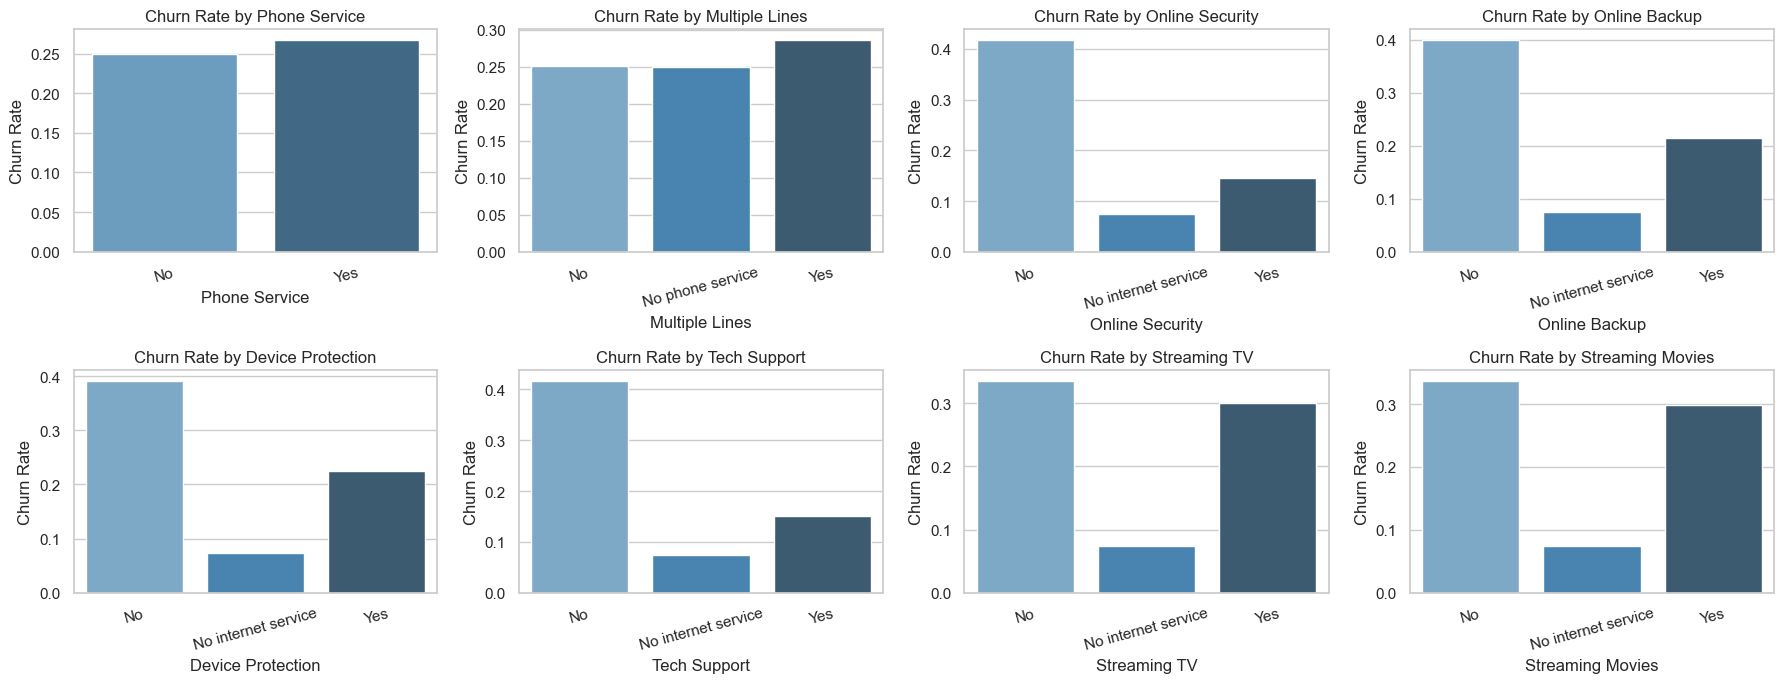

In [10]:
service_cols = ['Phone Service', 'Multiple Lines', 'Online Security', 'Online Backup',
                'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(service_cols):
    churn_rate = df.groupby(col)['Churn Value'].mean().reset_index()
    sns.barplot(data=churn_rate, x=col, y='Churn Value', ax=axes[i], palette='Blues_d')
    axes[i].set_title('Churn Rate by ' + col)
    axes[i].set_ylabel('Churn Rate')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../outputs/figures/05_service_churn_rates.png', dpi=150, bbox_inches='tight')
plt.show()